# Verify [[5,1,3]] Code Encoding Circuit

This notebook verifies that the encoding circuit used in `513DataGeneration.ipynb` correctly encodes the [[5,1,3]] quantum error correcting code.

## Verification Criteria

For a valid [[5,1,3]] code encoding, the encoded state must satisfy:

1. **Stabilizer Eigenvalue Check**: The encoded state must be a +1 eigenstate of all 4 stabilizers:
   - g1 = XZZXI
   - g2 = IXZZX
   - g3 = XIXZZ
   - g4 = ZXIXZ

2. **Logical Operator Check**: The logical operators should act correctly:
   - X̄ = XXXXX (logical X)
   - Z̄ = ZZZZZ (logical Z)

3. **Syndrome Measurement Check**: Syndrome measurement should return 0000 for no errors.

In [ ]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, Operator, Pauli
from qiskit_aer import AerSimulator

# from qiskit_ibm_runtime.fake_provider import FakeNighthawk

print("Imports complete")

Imports complete


## Define the [[5,1,3]] Code Stabilizers and Logical Operators

In [12]:
# [[5,1,3]] Code Stabilizers
STABILIZERS = [
    "XZZXI",  # g1
    "IXZZX",  # g2
    "XIXZZ",  # g3
    "ZXIXZ",  # g4
]

# Logical Operators
LOGICAL_X = "XXXXX"
LOGICAL_Z = "ZZZZZ"

print("Stabilizers:")
for i, stab in enumerate(STABILIZERS):
    print(f"  g{i+1} = {stab}")
print(f"\nLogical X̄ = {LOGICAL_X}")
print(f"Logical Z̄ = {LOGICAL_Z}")

Stabilizers:
  g1 = XZZXI
  g2 = IXZZX
  g3 = XIXZZ
  g4 = ZXIXZ

Logical X̄ = XXXXX
Logical Z̄ = ZZZZZ


## The Encoding Circuit from 513DataGeneration.ipynb

This is the encoding circuit we need to verify. It uses qubits 0-4 where:
- Qubits 0-3: Encoding ancillas
- Qubit 4: Data qubit (the logical qubit being encoded)

Encoding Circuit for |0̄⟩:


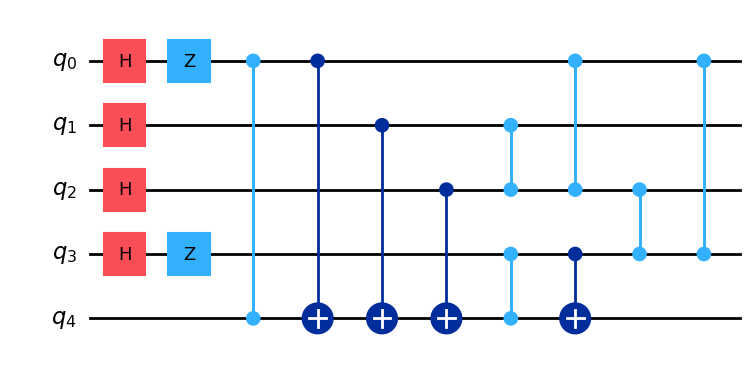

In [13]:
def build_encoding_circuit(initial_state='0'):
    """
    Build the [[5,1,3]] encoding circuit from 513DataGeneration.ipynb.
    
    Args:
        initial_state: '0' or '1' for the logical state to encode
    
    Returns:
        QuantumCircuit with 5 qubits
    """
    qc = QuantumCircuit(5)
    
    # Prepare initial state on data qubit (qubit 4)
    if initial_state == '1':
        qc.x(4)
    
    # Encoding circuit from 513DataGeneration.ipynb
    qc.h(0)
    qc.z(0)
    qc.cz(0, 4)
    qc.cx(0, 4)

    qc.h(1)
    qc.cx(1, 4)

    qc.h(2)
    qc.cx(2, 4)
    qc.cz(2, 1)
    qc.cz(2, 0)

    qc.h(3)
    qc.z(3)
    qc.cz(3, 4)
    qc.cx(3, 4)
    qc.cz(3, 2)
    qc.cz(3, 0)
    
    return qc

# Build and display the encoding circuit
encoding_circuit = build_encoding_circuit('0')
print("Encoding Circuit for |0̄⟩:")
encoding_circuit.draw('mpl', fold=-1)

## Test 1: Stabilizer Eigenvalue Check

A valid codeword must be a +1 eigenstate of all stabilizers.

For a state |ψ⟩ and stabilizer S:
- ⟨ψ|S|ψ⟩ = +1 means |ψ⟩ is a +1 eigenstate
- ⟨ψ|S|ψ⟩ = -1 means |ψ⟩ is a -1 eigenstate

In [14]:
def check_stabilizer_eigenvalues(circuit, stabilizers):
    """
    Check if the output state of a circuit is a +1 eigenstate of all stabilizers.
    
    Args:
        circuit: QuantumCircuit to test
        stabilizers: List of Pauli strings (e.g., ["XZZXI", ...])
    
    Returns:
        dict with results for each stabilizer
    """
    # Get the statevector after the circuit
    statevector = Statevector.from_instruction(circuit)
    
    results = {}
    print("Stabilizer Eigenvalue Check:")
    print("=" * 50)
    
    all_passed = True
    for i, stab_str in enumerate(stabilizers):
        # Create Pauli operator (Qiskit uses reversed ordering)
        # Qiskit Pauli("XYZ") means X on qubit 2, Y on qubit 1, Z on qubit 0
        # So we need to reverse the string
        pauli = Pauli(stab_str[::-1])
        
        # Calculate expectation value ⟨ψ|S|ψ⟩
        expectation = statevector.expectation_value(pauli)
        
        # Check if it's +1 (within numerical tolerance)
        is_plus_one = np.isclose(expectation.real, 1.0, atol=1e-10)
        is_minus_one = np.isclose(expectation.real, -1.0, atol=1e-10)
        
        status = "✓ PASS (+1)" if is_plus_one else ("✗ FAIL (-1)" if is_minus_one else f"✗ FAIL ({expectation.real:.4f})")
        if not is_plus_one:
            all_passed = False
        
        results[stab_str] = {
            'expectation': expectation,
            'is_plus_one': is_plus_one
        }
        
        print(f"  g{i+1} = {stab_str}: ⟨ψ|S|ψ⟩ = {expectation.real:+.6f}  {status}")
    
    print("=" * 50)
    if all_passed:
        print("All stabilizer checks PASSED!")
    else:
        print("Some stabilizer checks FAILED!")
    
    return results, all_passed

# Test the encoding for |0̄⟩
print("\nTesting encoding of |0⟩ → |0̄⟩:\n")
encoding_0 = build_encoding_circuit('0')
results_0, passed_0 = check_stabilizer_eigenvalues(encoding_0, STABILIZERS)


Testing encoding of |0⟩ → |0̄⟩:

Stabilizer Eigenvalue Check:
  g1 = XZZXI: ⟨ψ|S|ψ⟩ = +1.000000  ✓ PASS (+1)
  g2 = IXZZX: ⟨ψ|S|ψ⟩ = +1.000000  ✓ PASS (+1)
  g3 = XIXZZ: ⟨ψ|S|ψ⟩ = +1.000000  ✓ PASS (+1)
  g4 = ZXIXZ: ⟨ψ|S|ψ⟩ = +1.000000  ✓ PASS (+1)
All stabilizer checks PASSED!


In [15]:
# Test the encoding for |1̄⟩
print("\nTesting encoding of |1⟩ → |1̄⟩:\n")
encoding_1 = build_encoding_circuit('1')
results_1, passed_1 = check_stabilizer_eigenvalues(encoding_1, STABILIZERS)


Testing encoding of |1⟩ → |1̄⟩:

Stabilizer Eigenvalue Check:
  g1 = XZZXI: ⟨ψ|S|ψ⟩ = +1.000000  ✓ PASS (+1)
  g2 = IXZZX: ⟨ψ|S|ψ⟩ = +1.000000  ✓ PASS (+1)
  g3 = XIXZZ: ⟨ψ|S|ψ⟩ = +1.000000  ✓ PASS (+1)
  g4 = ZXIXZ: ⟨ψ|S|ψ⟩ = +1.000000  ✓ PASS (+1)
All stabilizer checks PASSED!


## Test 2: Logical Operator Check

The logical operators should satisfy:
- Z̄|0̄⟩ = +|0̄⟩ (eigenvalue +1)
- Z̄|1̄⟩ = -|1̄⟩ (eigenvalue -1)
- X̄|0̄⟩ = |1̄⟩ (flips the logical state)

In [16]:
def check_logical_operators(encoding_0_circuit, encoding_1_circuit):
    """
    Check that logical operators act correctly on encoded states.
    """
    # Get statevectors
    state_0_bar = Statevector.from_instruction(encoding_0_circuit)
    state_1_bar = Statevector.from_instruction(encoding_1_circuit)
    
    # Create logical operators (reversed for Qiskit)
    logical_z = Pauli(LOGICAL_Z[::-1])
    logical_x = Pauli(LOGICAL_X[::-1])
    
    print("Logical Operator Check:")
    print("=" * 50)
    
    # Check Z̄|0̄⟩ = +|0̄⟩
    z_exp_0 = state_0_bar.expectation_value(logical_z)
    z_check_0 = np.isclose(z_exp_0.real, 1.0, atol=1e-10)
    print(f"  Z̄|0̄⟩: ⟨0̄|Z̄|0̄⟩ = {z_exp_0.real:+.6f}  {'✓ PASS (should be +1)' if z_check_0 else '✗ FAIL'}")
    
    # Check Z̄|1̄⟩ = -|1̄⟩
    z_exp_1 = state_1_bar.expectation_value(logical_z)
    z_check_1 = np.isclose(z_exp_1.real, -1.0, atol=1e-10)
    print(f"  Z̄|1̄⟩: ⟨1̄|Z̄|1̄⟩ = {z_exp_1.real:+.6f}  {'✓ PASS (should be -1)' if z_check_1 else '✗ FAIL'}")
    
    # Check X̄|0̄⟩ = |1̄⟩ by computing overlap
    # Apply X̄ to |0̄⟩ and check if it equals |1̄⟩
    state_0_bar_after_x = state_0_bar.evolve(logical_x)
    overlap = np.abs(state_1_bar.inner(state_0_bar_after_x))**2
    x_check = np.isclose(overlap, 1.0, atol=1e-10)
    print(f"  X̄|0̄⟩ = |1̄⟩: |⟨1̄|X̄|0̄⟩|² = {overlap:.6f}  {'✓ PASS (should be 1)' if x_check else '✗ FAIL'}")
    
    # Check X̄|1̄⟩ = |0̄⟩
    state_1_bar_after_x = state_1_bar.evolve(logical_x)
    overlap_2 = np.abs(state_0_bar.inner(state_1_bar_after_x))**2
    x_check_2 = np.isclose(overlap_2, 1.0, atol=1e-10)
    print(f"  X̄|1̄⟩ = |0̄⟩: |⟨0̄|X̄|1̄⟩|² = {overlap_2:.6f}  {'✓ PASS (should be 1)' if x_check_2 else '✗ FAIL'}")
    
    print("=" * 50)
    
    all_passed = z_check_0 and z_check_1 and x_check and x_check_2
    if all_passed:
        print("All logical operator checks PASSED!")
    else:
        print("Some logical operator checks FAILED!")
    
    return all_passed

# Run logical operator check
print()
logical_passed = check_logical_operators(encoding_0, encoding_1)


Logical Operator Check:
  Z̄|0̄⟩: ⟨0̄|Z̄|0̄⟩ = +1.000000  ✓ PASS (should be +1)
  Z̄|1̄⟩: ⟨1̄|Z̄|1̄⟩ = -1.000000  ✓ PASS (should be -1)
  X̄|0̄⟩ = |1̄⟩: |⟨1̄|X̄|0̄⟩|² = 1.000000  ✓ PASS (should be 1)
  X̄|1̄⟩ = |0̄⟩: |⟨0̄|X̄|1̄⟩|² = 1.000000  ✓ PASS (should be 1)
All logical operator checks PASSED!


## Test 3: Syndrome Measurement Circuit Check

Verify that the syndrome measurement circuit (as used in 513DataGeneration.ipynb) returns 0000 for an error-free encoded state.

Full Encoding + Syndrome Measurement Circuit:


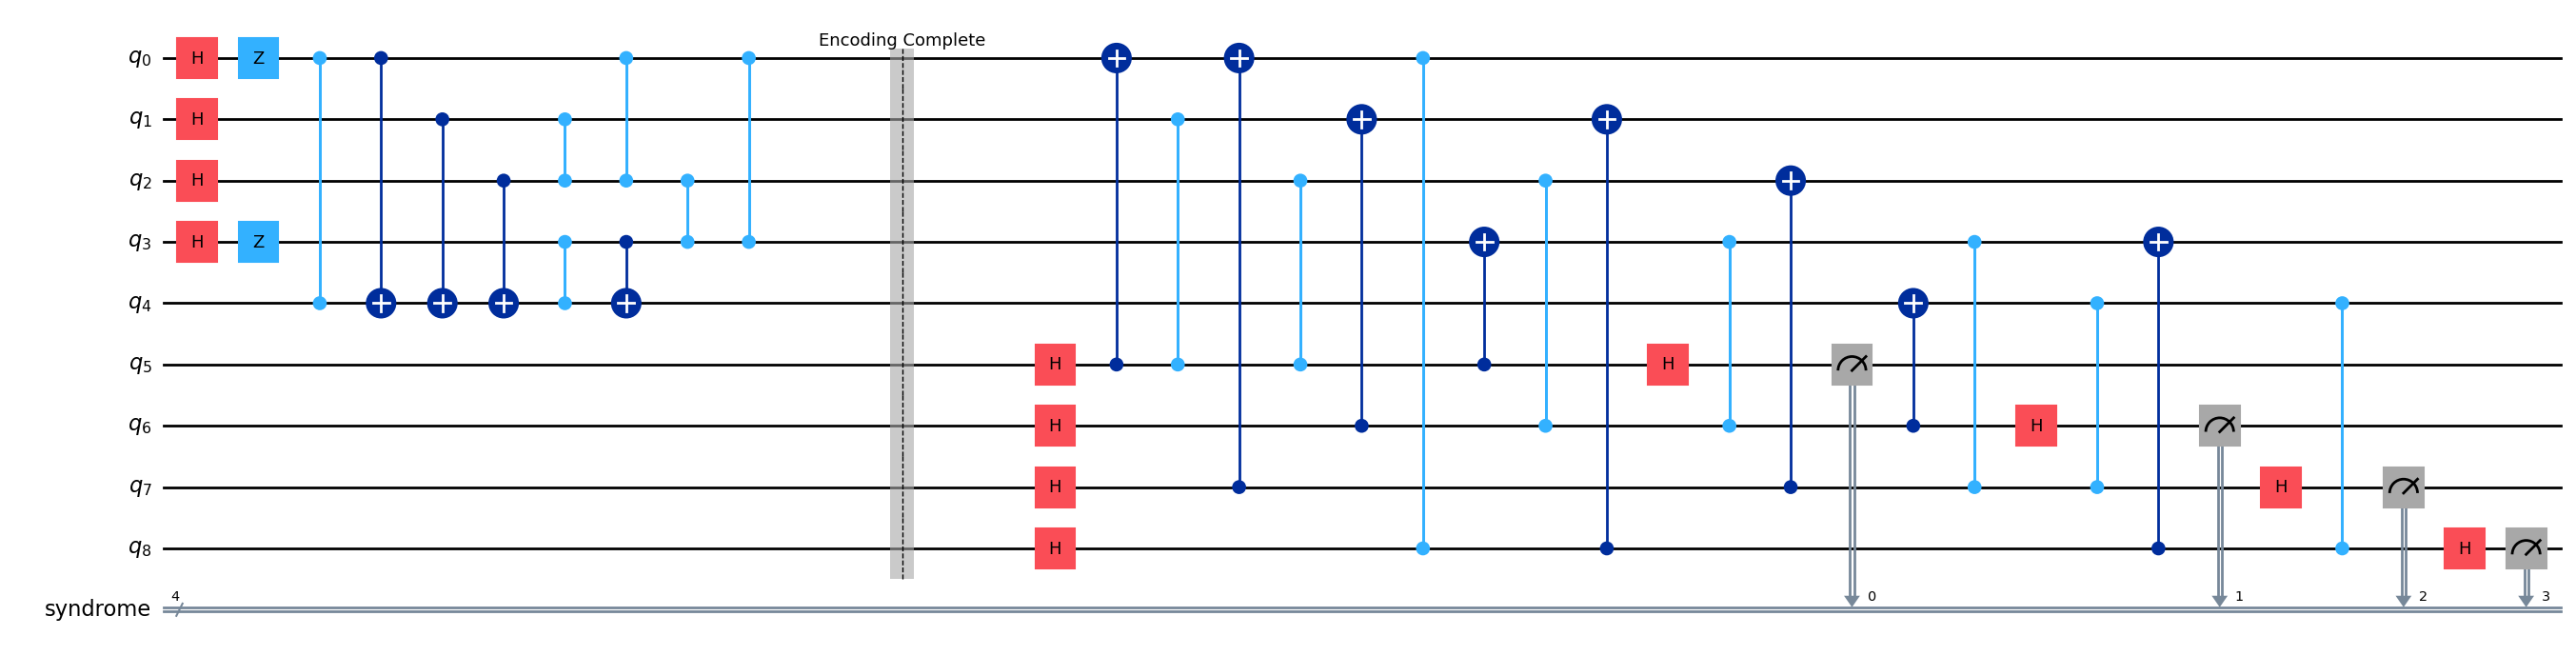

In [17]:
def build_full_encoding_and_syndrome_circuit(initial_state='0'):
    """
    Build complete circuit: encoding + syndrome measurement.
    Uses 9 qubits: 0-4 for code, 5-8 for syndrome ancillas.
    """
    qc = QuantumCircuit(9)
    syndrome_bits = ClassicalRegister(4, name='syndrome')
    qc.add_register(syndrome_bits)
    
    # Initial state on data qubit (qubit 4)
    if initial_state == '1':
        qc.x(4)
    
    # === ENCODING (from 513DataGeneration.ipynb) ===
    qc.h(0)
    qc.z(0)
    qc.cz(0, 4)
    qc.cx(0, 4)

    qc.h(1)
    qc.cx(1, 4)

    qc.h(2)
    qc.cx(2, 4)
    qc.cz(2, 1)
    qc.cz(2, 0)

    qc.h(3)
    qc.z(3)
    qc.cz(3, 4)
    qc.cx(3, 4)
    qc.cz(3, 2)
    qc.cz(3, 0)
    
    qc.barrier(label='Encoding Complete')
    
    # === SYNDROME MEASUREMENT (from 513DataGeneration.ipynb) ===
    stabilizers = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
    
    for idx, stabilizer in enumerate(stabilizers):
        ancilla = idx + 5  # Ancillas are qubits 5-8
        qc.h(ancilla)
        
        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(ancilla, qubit_idx)
            elif pauli == 'Z':
                qc.cz(ancilla, qubit_idx)
        
        qc.h(ancilla)
        qc.measure(ancilla, syndrome_bits[idx])
    
    return qc

# Build and display the full circuit
full_circuit = build_full_encoding_and_syndrome_circuit('0')
print("Full Encoding + Syndrome Measurement Circuit:")
full_circuit.draw('mpl', fold=-1)

In [18]:
def test_syndrome_measurement(initial_state='0', shots=10000):
    """
    Test that syndrome measurement returns 0000 for error-free encoded state.
    """
    circuit = build_full_encoding_and_syndrome_circuit(initial_state)
    
    # Use statevector simulator (no noise)
    simulator = AerSimulator(method='statevector')
    compiled = transpile(circuit, simulator)
    result = simulator.run(compiled, shots=shots).result()
    counts = result.get_counts()
    
    print(f"Syndrome Measurement Test (|{initial_state}⟩ → |{initial_state}̄⟩):")
    print("=" * 50)
    print(f"  Shots: {shots}")
    print(f"  Results: {counts}")
    
    # Check if all results are '0000'
    if counts == {'0000': shots}:
        print(f"  ✓ PASS: All {shots} shots returned syndrome 0000")
        return True
    else:
        print(f"  ✗ FAIL: Expected all 0000, got {counts}")
        return False

# Test syndrome for |0̄⟩ and |1̄⟩
print()
syndrome_0_passed = test_syndrome_measurement('0')
print()
syndrome_1_passed = test_syndrome_measurement('1')

Syndrome Measurement Test (|0⟩ → |0̄⟩):
  Shots: 10000
  Results: {'0000': 10000}
  ✓ PASS: All 10000 shots returned syndrome 0000

Syndrome Measurement Test (|1⟩ → |1̄⟩):
  Shots: 10000
  Results: {'0000': 10000}
  ✓ PASS: All 10000 shots returned syndrome 0000


## Summary

In [19]:
print("\n" + "=" * 60)
print("VERIFICATION SUMMARY")
print("=" * 60)

print(f"\n1. Stabilizer Check (|0̄⟩): {'✓ PASSED' if passed_0 else '✗ FAILED'}")
print(f"2. Stabilizer Check (|1̄⟩): {'✓ PASSED' if passed_1 else '✗ FAILED'}")
print(f"3. Logical Operator Check:  {'✓ PASSED' if logical_passed else '✗ FAILED'}")
print(f"4. Syndrome Check (|0̄⟩):    {'✓ PASSED' if syndrome_0_passed else '✗ FAILED'}")
print(f"5. Syndrome Check (|1̄⟩):    {'✓ PASSED' if syndrome_1_passed else '✗ FAILED'}")

all_tests_passed = passed_0 and passed_1 and logical_passed and syndrome_0_passed and syndrome_1_passed

print("\n" + "=" * 60)
if all_tests_passed:
    print("ALL TESTS PASSED! The encoding circuit is correct.")
else:
    print("SOME TESTS FAILED! The encoding circuit needs review.")
print("=" * 60)


VERIFICATION SUMMARY

1. Stabilizer Check (|0̄⟩): ✓ PASSED
2. Stabilizer Check (|1̄⟩): ✓ PASSED
3. Logical Operator Check:  ✓ PASSED
4. Syndrome Check (|0̄⟩):    ✓ PASSED
5. Syndrome Check (|1̄⟩):    ✓ PASSED

ALL TESTS PASSED! The encoding circuit is correct.


## Bonus: Test Error Detection

Verify that the syndrome correctly detects single-qubit errors.

In [20]:
def test_error_detection():
    """
    Test that single-qubit errors produce non-zero syndromes.
    """
    print("Error Detection Test:")
    print("=" * 60)
    
    simulator = AerSimulator(method='statevector')
    shots = 1000
    
    errors_detected = 0
    total_errors = 0
    
    for error_qubit in range(5):
        for error_type in ['X', 'Y', 'Z']:
            total_errors += 1
            
            # Build circuit with error
            qc = QuantumCircuit(9)
            syndrome_bits = ClassicalRegister(4, name='syndrome')
            qc.add_register(syndrome_bits)
            
            # Encoding
            qc.h(0); qc.z(0); qc.cz(0, 4); qc.cx(0, 4)
            qc.h(1); qc.cx(1, 4)
            qc.h(2); qc.cx(2, 4); qc.cz(2, 1); qc.cz(2, 0)
            qc.h(3); qc.z(3); qc.cz(3, 4); qc.cx(3, 4); qc.cz(3, 2); qc.cz(3, 0)
            
            # Inject error
            if error_type == 'X':
                qc.x(error_qubit)
            elif error_type == 'Y':
                qc.y(error_qubit)
            elif error_type == 'Z':
                qc.z(error_qubit)
            
            # Syndrome measurement
            stabilizers = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
            for idx, stabilizer in enumerate(stabilizers):
                ancilla = idx + 5
                qc.h(ancilla)
                for qubit_idx, pauli in enumerate(stabilizer):
                    if pauli == 'X':
                        qc.cx(ancilla, qubit_idx)
                    elif pauli == 'Z':
                        qc.cz(ancilla, qubit_idx)
                qc.h(ancilla)
                qc.measure(ancilla, syndrome_bits[idx])
            
            # Run
            compiled = transpile(qc, simulator)
            result = simulator.run(compiled, shots=shots).result()
            counts = result.get_counts()
            
            # Check syndrome is non-zero
            syndrome_val = list(counts.keys())[0]
            is_detected = syndrome_val != '0000'
            if is_detected:
                errors_detected += 1
            
            status = "✓" if is_detected else "✗"
            print(f"  {error_type} error on qubit {error_qubit}: syndrome = {syndrome_val}  {status}")
    
    print("=" * 60)
    print(f"Errors detected: {errors_detected}/{total_errors}")
    
    return errors_detected == total_errors

print()
error_detection_passed = test_error_detection()


Error Detection Test:
  X error on qubit 0: syndrome = 1000  ✓
  Y error on qubit 0: syndrome = 1101  ✓
  Z error on qubit 0: syndrome = 0101  ✓
  X error on qubit 1: syndrome = 0001  ✓
  Y error on qubit 1: syndrome = 1011  ✓
  Z error on qubit 1: syndrome = 1010  ✓
  X error on qubit 2: syndrome = 0011  ✓
  Y error on qubit 2: syndrome = 0111  ✓
  Z error on qubit 2: syndrome = 0100  ✓
  X error on qubit 3: syndrome = 0110  ✓
  Y error on qubit 3: syndrome = 1111  ✓
  Z error on qubit 3: syndrome = 1001  ✓
  X error on qubit 4: syndrome = 1100  ✓
  Y error on qubit 4: syndrome = 1110  ✓
  Z error on qubit 4: syndrome = 0010  ✓
Errors detected: 15/15


# Ground Truth Measurement Comparison

We compare two approaches for measuring ground truth Pauli error rates:

**Option 1: Measure ALL 5 Qubits**
- Transport all 5 code qubits through the channel
- Measure each qubit in X, Y, Z bases
- Average the error rates across all 5 qubits

**Option 2: Derive from Syndrome Distribution**
- Use the syndrome histogram from encoded transport
- Fit (px, py, pz) parameters that best explain the observed syndromes
- Uses the mathematical model from `five_qubit_code.py`

Setup complete!
Network edges: [(0, 1), (0, 3), (1, 2), (1, 4), (2, 5), (3, 4), (4, 5)]
Total qubits: 61


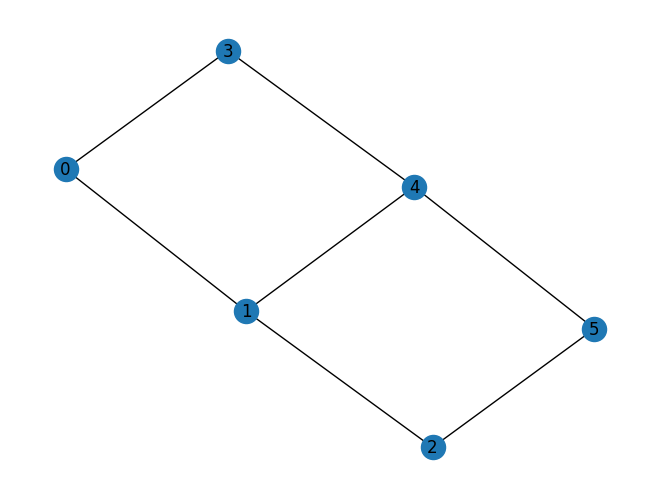

In [21]:
# =============================================================================
# SETUP: Network Topology and Physical Qubit Mapping
# =============================================================================
import networkx as nx
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez
import random

# Network topology
node_names = [0, 1, 2, 3, 4, 5]
network_graph = nx.Graph()
network_graph.add_nodes_from(node_names)
network_graph.add_edges_from([(0, 1), (1, 2), (0, 3), (1, 4), (2, 5), (3, 4), (4, 5)])

# Fixed physical qubit mapping (same as 513DataGeneration.ipynb)
NODE_PHYSICAL_QUBITS = {
    0: list(range(0, 9)),
    1: list(range(9, 18)),
    2: list(range(18, 27)),
    3: list(range(27, 36)),
    4: list(range(36, 45)),
    5: list(range(45, 54)),
}

PATH_PHYSICAL_QUBITS = {
    (0, 1): [54],
    (0, 3): [55],
    (1, 2): [56],
    (1, 4): [57],
    (2, 5): [58],
    (3, 4): [59],
    (4, 5): [60],
}

TOTAL_QUBITS = 61

# Noise model from FakeFez
fez_backend = FakeFez()
noise_model = NoiseModel.from_backend(fez_backend)

# Noisy simulator
NOISY_SIM = AerSimulator(noise_model=noise_model, method='matrix_product_state')
NUM_SHOTS = 8192  # More shots for better statistics

print("Setup complete!")
print(f"Network edges: {list(network_graph.edges())}")
print(f"Total qubits: {TOTAL_QUBITS}")
nx.draw(network_graph, with_labels=True)

## Option 1: Measure Ground Truth on ALL 5 Qubits

Transport all 5 code qubits (not just the data qubit) and measure error rates for each.

In [22]:
# =============================================================================
# OPTION 1: Measure Ground Truth on ALL 5 Qubits
# =============================================================================

def build_5qubit_ground_truth_circuit(source, sink, measurement_basis='Z'):
    """
    Build a circuit that transports ALL 5 code qubits and measures each.
    
    This gives us the error rate experienced by each physical qubit,
    which we can then average to get an effective edge error rate.
    """
    source_qubits = NODE_PHYSICAL_QUBITS[source][:5]  # Code qubits 0-4
    sink_qubits = NODE_PHYSICAL_QUBITS[sink][:5]
    
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS[edge_key]
    
    qc = QuantumCircuit(TOTAL_QUBITS)
    creg = ClassicalRegister(5, name='measurements')
    qc.add_register(creg)
    
    # Prepare each qubit in the appropriate basis state
    for i in range(5):
        if measurement_basis == 'X':
            qc.h(source_qubits[i])
        elif measurement_basis == 'Y':
            qc.h(source_qubits[i])
            qc.s(source_qubits[i])
        # Z basis: no preparation needed (already |0⟩)
    
    # Transport all 5 qubits through the path
    for i in range(5):
        qc.swap(source_qubits[i], path_qubits[0])
        qc.swap(path_qubits[0], sink_qubits[i])
    
    # Rotate back and measure each qubit
    for i in range(5):
        if measurement_basis == 'X':
            qc.h(sink_qubits[i])
        elif measurement_basis == 'Y':
            qc.sdg(sink_qubits[i])
            qc.h(sink_qubits[i])
        
        qc.measure(sink_qubits[i], creg[i])
    
    return qc


def calculate_5qubit_pauli_rates(source, sink, shots=NUM_SHOTS):
    """
    Calculate Pauli error rates by measuring all 5 qubits in X, Y, Z bases.
    Returns per-qubit rates and averaged rates.
    """
    # Build and run circuits for each basis
    results = {}
    for basis in ['Z', 'X', 'Y']:
        circuit = build_5qubit_ground_truth_circuit(source, sink, basis)
        compiled = transpile(circuit, NOISY_SIM, optimization_level=0)
        job_result = NOISY_SIM.run(compiled, shots=shots).result()
        results[basis] = job_result.get_counts()
    
    # Calculate error rate for each qubit in each basis
    per_qubit_errors = {basis: [] for basis in ['Z', 'X', 'Y']}
    
    for basis in ['Z', 'X', 'Y']:
        counts = results[basis]
        for qubit_idx in range(5):
            error_count = 0
            total = 0
            for bitstring, count in counts.items():
                total += count
                # Qiskit bitstring is reversed: bitstring[0] is the last qubit measured
                bit = bitstring[4 - qubit_idx]  # Correct for Qiskit ordering
                if bit == '1':  # Error occurred
                    error_count += count
            per_qubit_errors[basis].append(error_count / total)
    
    # Calculate per-qubit Pauli rates using tomography equations
    per_qubit_px = []
    per_qubit_py = []
    per_qubit_pz = []
    
    for i in range(5):
        E_z = per_qubit_errors['Z'][i]  # P(X) + P(Y)
        E_x = per_qubit_errors['X'][i]  # P(Z) + P(Y)
        E_y = per_qubit_errors['Y'][i]  # P(X) + P(Z)
        
        px = max(0, 0.5 * (E_z + E_y - E_x))
        py = max(0, 0.5 * (E_z + E_x - E_y))
        pz = max(0, 0.5 * (E_x + E_y - E_z))
        
        per_qubit_px.append(px)
        per_qubit_py.append(py)
        per_qubit_pz.append(pz)
    
    # Average across all 5 qubits
    avg_px = np.mean(per_qubit_px)
    avg_py = np.mean(per_qubit_py)
    avg_pz = np.mean(per_qubit_pz)
    
    return {
        'per_qubit_px': per_qubit_px,
        'per_qubit_py': per_qubit_py,
        'per_qubit_pz': per_qubit_pz,
        'avg_px': avg_px,
        'avg_py': avg_py,
        'avg_pz': avg_pz,
        'per_qubit_errors': per_qubit_errors,
    }


# Test on one edge
print("Testing Option 1 on edge (0, 1)...")
result_opt1 = calculate_5qubit_pauli_rates(0, 1)

print("\nPer-qubit Pauli error rates:")
print("-" * 60)
for i in range(5):
    print(f"  Qubit {i}: px={result_opt1['per_qubit_px'][i]:.6f}, "
          f"py={result_opt1['per_qubit_py'][i]:.6f}, "
          f"pz={result_opt1['per_qubit_pz'][i]:.6f}")

print("-" * 60)
print(f"  Average: px={result_opt1['avg_px']:.6f}, "
      f"py={result_opt1['avg_py']:.6f}, "
      f"pz={result_opt1['avg_pz']:.6f}")

Testing Option 1 on edge (0, 1)...

Per-qubit Pauli error rates:
------------------------------------------------------------
  Qubit 0: px=0.005859, py=0.005493, pz=0.006836
  Qubit 1: px=0.000916, py=0.003479, pz=0.004700
  Qubit 2: px=0.005005, py=0.008911, pz=0.005981
  Qubit 3: px=0.010437, py=0.012146, pz=0.016296
  Qubit 4: px=0.006470, py=0.006226, pz=0.006348
------------------------------------------------------------
  Average: px=0.005737, py=0.007251, pz=0.008032


## Option 2: Derive Ground Truth from Syndrome Distribution

Use the syndrome histogram to fit (px, py, pz) parameters that best explain the observed syndromes. This uses the mathematical model from `five_qubit_code.py`.

In [23]:
# =============================================================================
# OPTION 2: Derive Ground Truth from Syndrome Distribution
# =============================================================================
from scipy.optimize import minimize

# Syndrome calculation functions (from five_qubit_code.py)
def pauli_mul(p, q):
    """Multiply two single-qubit Pauli operators (ignoring phase)."""
    if p == 'I': return q
    if q == 'I': return p
    if p == q: return 'I'
    if {p, q} == {'X', 'Y'}: return 'Z'
    if {p, q} == {'Y', 'Z'}: return 'X'
    if {p, q} == {'Z', 'X'}: return 'Y'

def commutes(p_str, q_str):
    """Check if two Pauli strings commute."""
    anticommute_count = sum(1 for p, q in zip(p_str, q_str) 
                           if p != 'I' and q != 'I' and p != q)
    return anticommute_count % 2 == 0

def syndrome(error_5):
    """Calculate the syndrome of a 5-qubit error."""
    stabs = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
    return tuple(0 if commutes(error_5, s) else 1 for s in stabs)

def compose_errors(errors_list):
    """Compose multiple 5-qubit Pauli errors."""
    if not errors_list:
        return "IIIII"
    result = list(errors_list[0])
    for error in errors_list[1:]:
        for i in range(5):
            result[i] = pauli_mul(result[i], error[i])
    return ''.join(result)


def simulate_syndrome_histogram(px, py, pz, num_samples=100000):
    """
    Simulate syndrome histogram for given Pauli error probabilities.
    
    Assumes each of the 5 code qubits independently experiences
    Pauli errors with probabilities (px, py, pz).
    """
    pi = max(0, 1.0 - px - py - pz)
    probs = [pi, px, py, pz]
    paulis = ['I', 'X', 'Y', 'Z']
    
    histogram = np.zeros(16, dtype=np.float64)
    
    for _ in range(num_samples):
        # Sample error for each of 5 qubits
        error_str = ''.join(random.choices(paulis, weights=probs, k=5))
        
        # Calculate syndrome
        syn = syndrome(error_str)
        syn_idx = syn[0] + 2*syn[1] + 4*syn[2] + 8*syn[3]
        histogram[syn_idx] += 1
    
    return histogram / num_samples  # Normalize to probability distribution


def fit_params_from_histogram(observed_histogram, num_sim_samples=50000):
    """
    Fit (px, py, pz) parameters that best explain the observed syndrome histogram.
    Uses KL divergence as the loss function.
    """
    # Normalize observed histogram
    observed_probs = observed_histogram / observed_histogram.sum()
    
    def loss(params):
        px, py, pz = params
        # Ensure valid probabilities
        if px < 0 or py < 0 or pz < 0 or px + py + pz > 1:
            return 1e10
        
        simulated_probs = simulate_syndrome_histogram(px, py, pz, num_sim_samples)
        
        # KL divergence (with small epsilon for numerical stability)
        eps = 1e-10
        kl_div = np.sum(observed_probs * np.log((observed_probs + eps) / (simulated_probs + eps)))
        
        return kl_div
    
    # Initial guess based on syndrome error rate
    syndrome_error_rate = 1 - observed_probs[0]
    initial_guess = [syndrome_error_rate / 15, syndrome_error_rate / 15, syndrome_error_rate / 15]
    
    # Optimize
    result = minimize(
        loss,
        initial_guess,
        method='Nelder-Mead',
        options={'maxiter': 500, 'xatol': 1e-6}
    )
    
    return {
        'px': max(0, result.x[0]),
        'py': max(0, result.x[1]),
        'pz': max(0, result.x[2]),
        'loss': result.fun,
        'success': result.success,
    }


# Generate syndrome data for edge (0,1) with FULL encoding circuit
def build_encoded_transport_circuit(source, sink):
    """Build the full encoded transport circuit (same as 513DataGeneration)."""
    source_qubits = NODE_PHYSICAL_QUBITS[source]
    sink_qubits = NODE_PHYSICAL_QUBITS[sink]
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS[edge_key]
    
    qc = QuantumCircuit(TOTAL_QUBITS)
    syndrome_bits = ClassicalRegister(4, name='syndrome')
    qc.add_register(syndrome_bits)
    
    # Encoding
    qc.h(source_qubits[0]); qc.z(source_qubits[0])
    qc.cz(source_qubits[0], source_qubits[4]); qc.cx(source_qubits[0], source_qubits[4])
    qc.h(source_qubits[1]); qc.cx(source_qubits[1], source_qubits[4])
    qc.h(source_qubits[2]); qc.cx(source_qubits[2], source_qubits[4])
    qc.cz(source_qubits[2], source_qubits[1]); qc.cz(source_qubits[2], source_qubits[0])
    qc.h(source_qubits[3]); qc.z(source_qubits[3])
    qc.cz(source_qubits[3], source_qubits[4]); qc.cx(source_qubits[3], source_qubits[4])
    qc.cz(source_qubits[3], source_qubits[2]); qc.cz(source_qubits[3], source_qubits[0])
    
    # Transport all 5 code qubits
    for i in range(5):
        qc.swap(source_qubits[i], path_qubits[0])
        qc.swap(path_qubits[0], sink_qubits[i])
    
    # Syndrome measurement
    stabilizers = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
    for idx, stab in enumerate(stabilizers):
        ancilla = sink_qubits[5 + idx]
        qc.h(ancilla)
        for q_idx, pauli in enumerate(stab):
            if pauli == 'X': qc.cx(ancilla, sink_qubits[q_idx])
            elif pauli == 'Z': qc.cz(ancilla, sink_qubits[q_idx])
        qc.h(ancilla)
        qc.measure(ancilla, syndrome_bits[idx])
    
    return qc


print("Testing Option 2 on edge (0, 1)...")
print("Step 1: Running encoded transport circuit with noise...")

circuit = build_encoded_transport_circuit(0, 1)
compiled = transpile(circuit, NOISY_SIM, optimization_level=0)
result = NOISY_SIM.run(compiled, shots=NUM_SHOTS).result()
counts = result.get_counts()

# Build histogram
observed_histogram = np.zeros(16, dtype=np.float64)
for syndrome_str, count in counts.items():
    idx = int(syndrome_str, 2)
    observed_histogram[idx] = count

print(f"  Observed histogram: {observed_histogram}")
print(f"  Syndrome error rate: {1 - observed_histogram[0]/observed_histogram.sum():.4f}")

print("\nStep 2: Fitting (px, py, pz) from syndrome distribution...")
result_opt2 = fit_params_from_histogram(observed_histogram)

print(f"\n  Fitted parameters:")
print(f"    px = {result_opt2['px']:.6f}")
print(f"    py = {result_opt2['py']:.6f}")
print(f"    pz = {result_opt2['pz']:.6f}")
print(f"    KL divergence = {result_opt2['loss']:.6f}")
print(f"    Optimization converged: {result_opt2['success']}")

Testing Option 2 on edge (0, 1)...
Step 1: Running encoded transport circuit with noise...
  Observed histogram: [7402.   38.  262.    9.  146.   34.   21.   32.   64.   38.   26.   34.
   17.   17.   31.   21.]
  Syndrome error rate: 0.0964

Step 2: Fitting (px, py, pz) from syndrome distribution...

  Fitted parameters:
    px = 0.006608
    py = 0.006434
    pz = 0.006680
    KL divergence = 0.041386
    Optimization converged: False


## Compare Option 1 vs Option 2 on All Edges

Run both methods on all network edges and compare the results.

In [24]:
# =============================================================================
# COMPARE OPTION 1 vs OPTION 2 on ALL EDGES
# =============================================================================

# Also include the ORIGINAL ground truth method (single qubit) for comparison
def calculate_original_ground_truth(source, sink, shots=NUM_SHOTS):
    """Original method: measure only the data qubit (index 4)."""
    source_qubits = NODE_PHYSICAL_QUBITS[source]
    sink_qubits = NODE_PHYSICAL_QUBITS[sink]
    edge_key = (min(source, sink), max(source, sink))
    path_qubits = PATH_PHYSICAL_QUBITS[edge_key]
    
    results = {}
    for basis in ['Z', 'X', 'Y']:
        qc = QuantumCircuit(TOTAL_QUBITS)
        creg = ClassicalRegister(1, name='c')
        qc.add_register(creg)
        
        source_qubit = source_qubits[4]  # Only data qubit
        sink_qubit = sink_qubits[4]
        
        if basis == 'X': qc.h(source_qubit)
        elif basis == 'Y': qc.h(source_qubit); qc.s(source_qubit)
        
        qc.swap(source_qubit, path_qubits[0])
        qc.swap(path_qubits[0], sink_qubit)
        
        if basis == 'X': qc.h(sink_qubit)
        elif basis == 'Y': qc.sdg(sink_qubit); qc.h(sink_qubit)
        
        qc.measure(sink_qubit, creg[0])
        
        compiled = transpile(qc, NOISY_SIM, optimization_level=0)
        job_result = NOISY_SIM.run(compiled, shots=shots).result()
        results[basis] = job_result.get_counts()
    
    # Calculate error rates
    E_z = results['Z'].get('1', 0) / shots
    E_x = results['X'].get('1', 0) / shots
    E_y = results['Y'].get('1', 0) / shots
    
    px = max(0, 0.5 * (E_z + E_y - E_x))
    py = max(0, 0.5 * (E_z + E_x - E_y))
    pz = max(0, 0.5 * (E_x + E_y - E_z))
    
    return {'px': px, 'py': py, 'pz': pz}


print("=" * 80)
print("COMPARING GROUND TRUTH MEASUREMENT METHODS")
print("=" * 80)

comparison_results = []

for edge in network_graph.edges():
    source, sink = edge
    print(f"\n{'='*80}")
    print(f"Edge {edge}")
    print(f"{'='*80}")
    
    # Original method (single qubit)
    print("\n[Original] Measuring single qubit (index 4)...")
    orig = calculate_original_ground_truth(source, sink)
    print(f"  px={orig['px']:.6f}, py={orig['py']:.6f}, pz={orig['pz']:.6f}")
    print(f"  Total: {orig['px'] + orig['py'] + orig['pz']:.6f}")
    
    # Option 1: All 5 qubits
    print("\n[Option 1] Measuring all 5 code qubits...")
    opt1 = calculate_5qubit_pauli_rates(source, sink)
    print(f"  px={opt1['avg_px']:.6f}, py={opt1['avg_py']:.6f}, pz={opt1['avg_pz']:.6f}")
    print(f"  Total: {opt1['avg_px'] + opt1['avg_py'] + opt1['avg_pz']:.6f}")
    
    # Option 2: Fit from syndrome
    print("\n[Option 2] Fitting from syndrome distribution...")
    circuit = build_encoded_transport_circuit(source, sink)
    compiled = transpile(circuit, NOISY_SIM, optimization_level=0)
    result = NOISY_SIM.run(compiled, shots=NUM_SHOTS).result()
    counts = result.get_counts()
    
    observed_histogram = np.zeros(16, dtype=np.float64)
    for syndrome_str, count in counts.items():
        idx = int(syndrome_str, 2)
        observed_histogram[idx] = count
    
    opt2 = fit_params_from_histogram(observed_histogram)
    print(f"  px={opt2['px']:.6f}, py={opt2['py']:.6f}, pz={opt2['pz']:.6f}")
    print(f"  Total: {opt2['px'] + opt2['py'] + opt2['pz']:.6f}")
    print(f"  KL divergence: {opt2['loss']:.6f}")
    
    comparison_results.append({
        'edge': edge,
        'original': orig,
        'option1': opt1,
        'option2': opt2,
        'syndrome_error_rate': 1 - observed_histogram[0]/observed_histogram.sum()
    })

print("\n" + "=" * 80)
print("DONE!")
print("=" * 80)

COMPARING GROUND TRUTH MEASUREMENT METHODS

Edge (0, 1)

[Original] Measuring single qubit (index 4)...
  px=0.003784, py=0.007690, pz=0.006714
  Total: 0.018188

[Option 1] Measuring all 5 code qubits...
  px=0.006287, py=0.007092, pz=0.007239
  Total: 0.020618

[Option 2] Fitting from syndrome distribution...
  px=0.006377, py=0.006272, pz=0.006769
  Total: 0.019418
  KL divergence: 0.041461

Edge (0, 3)

[Original] Measuring single qubit (index 4)...
  px=0.006714, py=0.003906, pz=0.005981
  Total: 0.016602

[Option 1] Measuring all 5 code qubits...
  px=0.004309, py=0.004309, pz=0.004480
  Total: 0.013098

[Option 2] Fitting from syndrome distribution...
  px=0.005342, py=0.005415, pz=0.005845
  Total: 0.016601
  KL divergence: 0.022691

Edge (1, 2)

[Original] Measuring single qubit (index 4)...
  px=0.008118, py=0.004700, pz=0.005676
  Total: 0.018494

[Option 1] Measuring all 5 code qubits...
  px=0.003784, py=0.004297, pz=0.004883
  Total: 0.012964

[Option 2] Fitting from synd

In [25]:
# =============================================================================
# SUMMARY TABLE
# =============================================================================
import pandas as pd

# Build summary dataframe
summary_data = []
for r in comparison_results:
    edge = r['edge']
    orig = r['original']
    opt1 = r['option1']
    opt2 = r['option2']
    
    orig_total = orig['px'] + orig['py'] + orig['pz']
    opt1_total = opt1['avg_px'] + opt1['avg_py'] + opt1['avg_pz']
    opt2_total = opt2['px'] + opt2['py'] + opt2['pz']
    
    summary_data.append({
        'Edge': str(edge),
        'Original (1q)': f"{orig_total:.4f}",
        'Option1 (5q avg)': f"{opt1_total:.4f}",
        'Option2 (fitted)': f"{opt2_total:.4f}",
        'Syndrome Err': f"{r['syndrome_error_rate']:.4f}",
        'Opt1/Orig': f"{opt1_total/orig_total:.2f}x" if orig_total > 0 else "N/A",
        'Opt2/Orig': f"{opt2_total/orig_total:.2f}x" if orig_total > 0 else "N/A",
    })

df = pd.DataFrame(summary_data)
print("\n" + "=" * 100)
print("SUMMARY: Total Error Rate (px + py + pz) Comparison")
print("=" * 100)
print(df.to_string(index=False))

print("\n\nKey Observations:")
print("-" * 80)
print("• Original (1q): Measures only qubit 4 - UNDERESTIMATES total noise")
print("• Option 1 (5q): Measures all 5 code qubits - better channel estimate")
print("• Option 2 (fitted): Fits params from syndrome - includes encoding/decoding noise")
print("• Option 2 should give params that best match what your model sees!")
print("-" * 80)


SUMMARY: Total Error Rate (px + py + pz) Comparison
  Edge Original (1q) Option1 (5q avg) Option2 (fitted) Syndrome Err Opt1/Orig Opt2/Orig
(0, 1)        0.0182           0.0206           0.0194       0.0951     1.13x     1.07x
(0, 3)        0.0166           0.0131           0.0166       0.0820     0.79x     1.00x
(1, 2)        0.0185           0.0130           0.0130       0.0642     0.70x     0.70x
(1, 4)        0.0184           0.0143           0.0278       0.1344     0.78x     1.51x
(2, 5)        0.0428           0.0261           0.0231       0.1134     0.61x     0.54x
(3, 4)        0.0205           0.0143           0.0302       0.1500     0.70x     1.47x
(4, 5)        0.0425           0.0269           0.0205       0.1008     0.63x     0.48x


Key Observations:
--------------------------------------------------------------------------------
• Original (1q): Measures only qubit 4 - UNDERESTIMATES total noise
• Option 1 (5q): Measures all 5 code qubits - better channel estimate
• Op

Validating Option 2 for edge (0, 1)

Fitted params: px=0.0064, py=0.0063, pz=0.0068

Syndrome   Observed     Simulated    Diff      
--------------------------------------------
0000       0.9025       0.9070       -0.0045
0001       0.0055       0.0060       -0.0005
0010       0.0349       0.0066       +0.0283
0011       0.0013       0.0062       -0.0049
0100       0.0166       0.0065       +0.0101
0101       0.0067       0.0064       +0.0003
0110       0.0015       0.0057       -0.0043
0111       0.0038       0.0062       -0.0024
1000       0.0060       0.0062       -0.0002
1001       0.0032       0.0064       -0.0032
1010       0.0032       0.0062       -0.0030
1011       0.0039       0.0059       -0.0020
1100       0.0031       0.0059       -0.0028
1101       0.0018       0.0064       -0.0046
1110       0.0033       0.0061       -0.0028
1111       0.0028       0.0062       -0.0034
--------------------------------------------
Total absolute difference: 0.0774
KL divergence: 0.041461

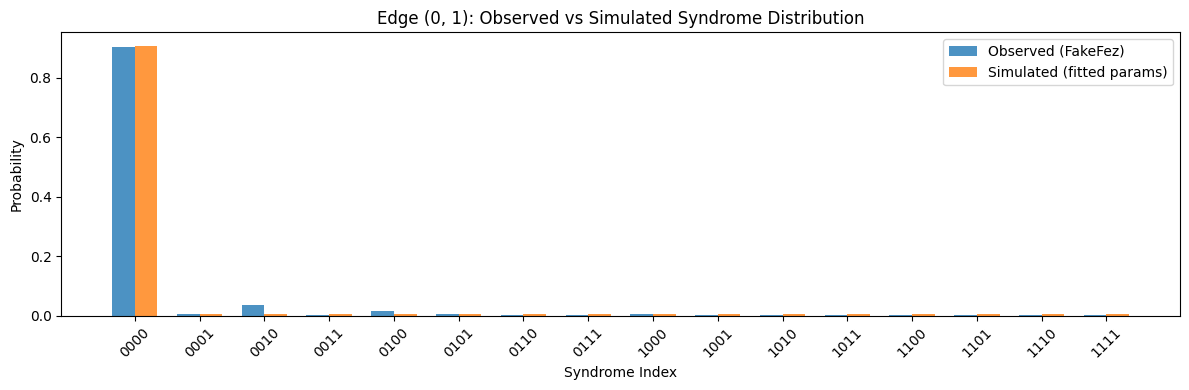

In [26]:
# =============================================================================
# VALIDATE OPTION 2: Compare Simulated vs Observed Histograms
# =============================================================================

def validate_fitted_params(edge_idx=0):
    """Validate that fitted params reproduce the observed histogram."""
    r = comparison_results[edge_idx]
    edge = r['edge']
    opt2 = r['option2']
    
    print(f"Validating Option 2 for edge {edge}")
    print("=" * 60)
    
    # Get observed histogram
    circuit = build_encoded_transport_circuit(edge[0], edge[1])
    compiled = transpile(circuit, NOISY_SIM, optimization_level=0)
    result = NOISY_SIM.run(compiled, shots=NUM_SHOTS).result()
    counts = result.get_counts()
    
    observed_histogram = np.zeros(16, dtype=np.float64)
    for syndrome_str, count in counts.items():
        idx = int(syndrome_str, 2)
        observed_histogram[idx] = count
    observed_probs = observed_histogram / observed_histogram.sum()
    
    # Simulate with fitted params
    simulated_probs = simulate_syndrome_histogram(
        opt2['px'], opt2['py'], opt2['pz'], 
        num_samples=100000
    )
    
    # Compare
    print(f"\nFitted params: px={opt2['px']:.4f}, py={opt2['py']:.4f}, pz={opt2['pz']:.4f}")
    print(f"\n{'Syndrome':<10} {'Observed':<12} {'Simulated':<12} {'Diff':<10}")
    print("-" * 44)
    
    total_abs_diff = 0
    for i in range(16):
        syn_str = format(i, '04b')
        diff = observed_probs[i] - simulated_probs[i]
        total_abs_diff += abs(diff)
        print(f"{syn_str:<10} {observed_probs[i]:.4f}       {simulated_probs[i]:.4f}       {diff:+.4f}")
    
    print("-" * 44)
    print(f"Total absolute difference: {total_abs_diff:.4f}")
    print(f"KL divergence: {opt2['loss']:.6f}")
    
    # Visual comparison
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(16)
    width = 0.35
    ax.bar(x - width/2, observed_probs, width, label='Observed (FakeFez)', alpha=0.8)
    ax.bar(x + width/2, simulated_probs, width, label='Simulated (fitted params)', alpha=0.8)
    ax.set_xlabel('Syndrome Index')
    ax.set_ylabel('Probability')
    ax.set_title(f'Edge {edge}: Observed vs Simulated Syndrome Distribution')
    ax.set_xticks(x)
    ax.set_xticklabels([format(i, '04b') for i in range(16)], rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Validate for first edge
validate_fitted_params(0)